# 第8章 Element-Wise：逐元素算子

向量加法每个输出只依赖两个同位置输入。我们从这个简单依赖出发，建立 HIP 和 Triton 基线，试一项工作粒度改动，再用同一组答案和时间判断是否保留。

前置：[第4章](../../part0-intro/chapter4/chapter4.ipynb)、[第5–7章](../../part1-profiling/chapter5/chapter5.ipynb)。对应[正文](../../../docs/part2-kernels/chapter8/index.md)。本页性能表和结果图都由你当前设备运行产生，不预设某个版本更快。


## 8.1 逐元素算子的数据依赖

逐元素加法满足 $c_i=a_i+b_i$，不同输出之间没有依赖，所以可以分别交给不同线程或 program。归约则需要把多个元素合到一个答案，后续章节会引入新的协作。

HIP 直接写线程下标；Triton 写一组 offsets。两种表达都必须覆盖全部元素并保护尾部。


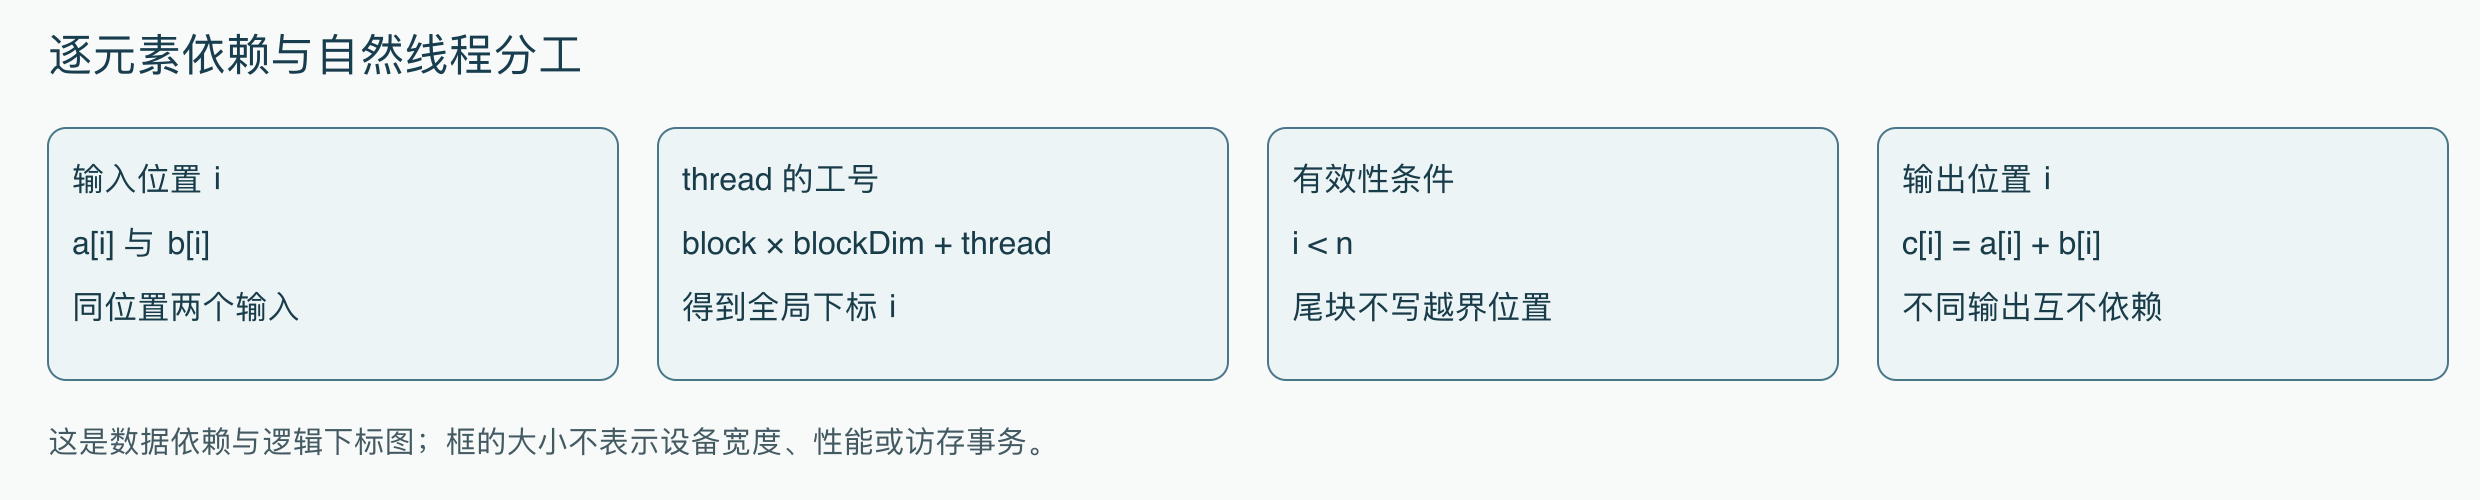

*一个线程处理一个输出的自然基线，不指定 wavefront 宽度。*


In [ ]:
%run ../../common/bootstrap.py

import torch
import triton
import triton.language as tl
import hello_gpu as gpu
from hello_gpu import learning, profiling
%load_ext hello_gpu
cfg = gpu.settings()
env = gpu.environment()
env


## 8.2 固定数学语义与正确性标准

先用四元素例子手算，再用固定 seed 的非均匀输入检查真正的 kernel。我们还检查不是 block/tile 整数倍的长度和带 storage offset 的连续切片；图中性能只比较相同数据与计时口径。


In [ ]:
a_small = torch.tensor([1.,-2.,3.,0.5])
b_small = torch.tensor([2.,4.,-3.,0.25])
a_small + b_small


## 8.3 建立成本模型和瓶颈假设

FP32 的算法数据量为 $12N$ Byte，加法次数为 $N$，AI 为 $1/12$ FLOP/Byte。我们先假设足够大的流式输入值得研究访问与工作分配；缓存、提交间隙和规模都可能改变本机观察。逻辑带宽不是硬件流量计数器。


In [ ]:
N = cfg['n'] + 17
print({'elements':N,'logical_bytes':12*N,'AI':1/12})


## 8.4 实现向量加法

### HIP 路线：自然基线

一线程一元素让相邻线程读取相邻地址。先编译它，再检查答案与测量。这里用 `int n` 接入 Tensor ABI；它与正文 `size_t` 版本的索引语义相同，当前输入范围须小于 int32 上限。


In [ ]:
%%hip hip_base --entry hip_base
__global__ void hip_base(const float* a, const float* b, float* c, int n) {
    int64_t i = static_cast<int64_t>(blockIdx.x) * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}


In [ ]:
a,b = learning.inputs(N,seed=cfg['seed'])
reference = a+b
outputs = {'HIP baseline':torch.empty_like(a)}
calls = {'HIP baseline':hip_base.prepare(a,b,block=cfg['block'],out=outputs['HIP baseline'])}
base = learning.compare(calls,reference=reference,outputs=outputs,
                        warmup=cfg['warmup'],repeat=cfg['repeat'],bytes_moved=12*N)
base


基线已经正确，下一步提出具体假设：减少大量 block，用 grid-stride 让每个线程继续处理后续元素，能否改善本机时间？循环会增加每线程工作，不保证提速。grid cap 根据实际 multiprocessor 数给一个起点，可以自行改。


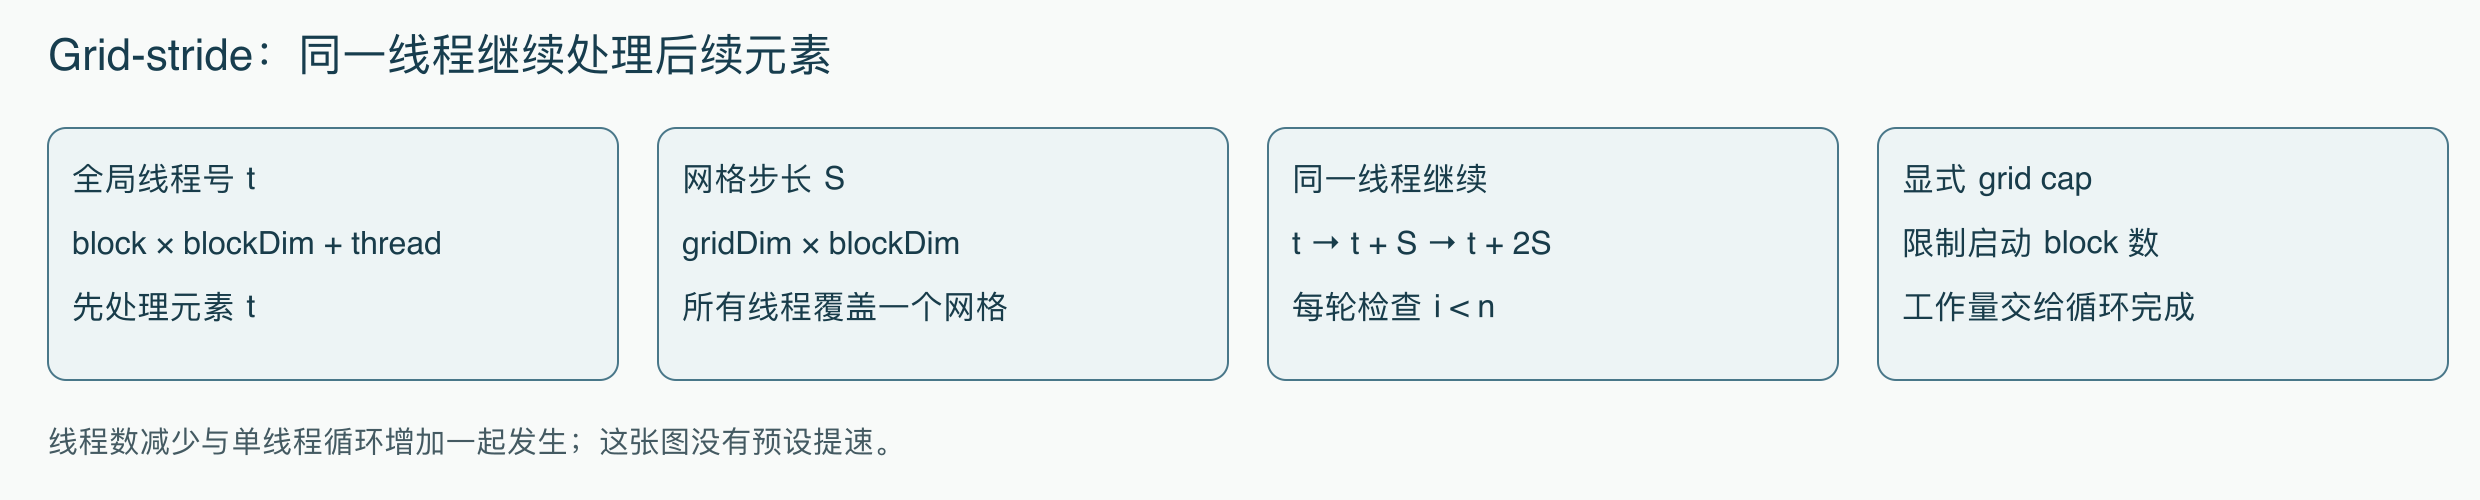

*下标和循环语义来自当前 kernel；grid cap 同时传入正式计时和 trace。*


In [ ]:
%%hip hip_grid --entry hip_grid
__global__ void hip_grid(const float* a, const float* b, float* c, int n) {
    int64_t i = static_cast<int64_t>(blockIdx.x) * blockDim.x + threadIdx.x;
    int64_t step = static_cast<int64_t>(gridDim.x) * blockDim.x;
    for (; i < n; i += step) c[i] = a[i] + b[i];
}


In [ ]:
grid_cap = torch.cuda.get_device_properties(a.device).multi_processor_count * 4
outputs['HIP grid-stride'] = torch.empty_like(a)
calls['HIP grid-stride'] = hip_grid.prepare(a,b,block=cfg['block'],grid_limit=grid_cap,
                                          out=outputs['HIP grid-stride'])
round_grid = learning.compare(calls,reference=reference,outputs=outputs,
                              warmup=cfg['warmup'],repeat=cfg['repeat'],bytes_moved=12*N)
round_grid


In [ ]:
learning.plot_comparison(round_grid,baseline='HIP baseline')


另一项改动是用 `float4` 表达四元素读写。指针必须对齐；连续切片也可能带偏移，所以先在 kernel 检查地址并为未对齐情况走标量循环。最后不足四个元素仍逐个写出。

这项表达会同时改变每线程元素数和编译结果；不能只看到 float4 就宣布物理事务减少。


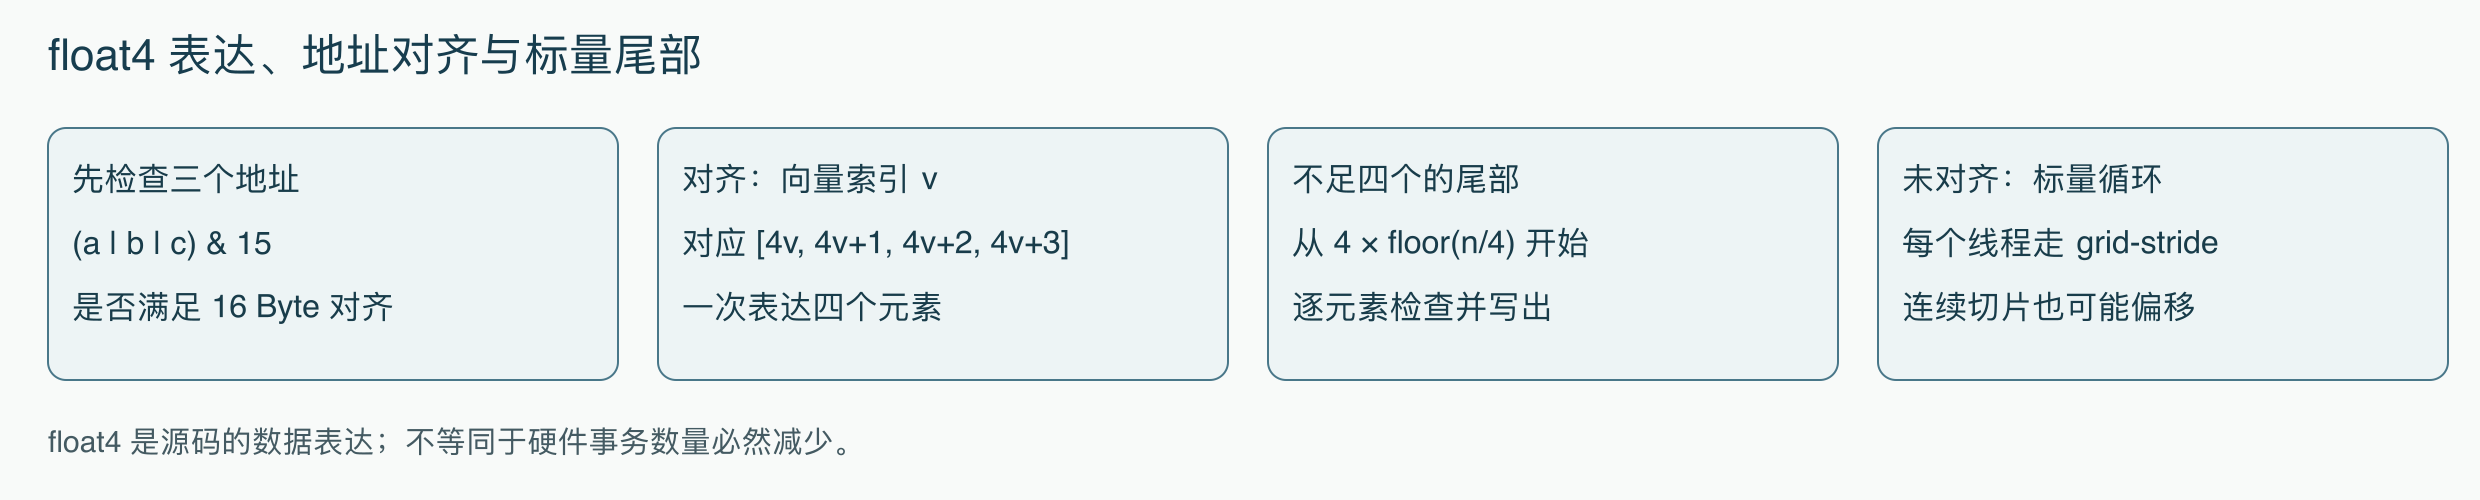

*先按真实地址选择路径，再覆盖尾部；各路径都需要正确性检查。*


In [ ]:
%%hip hip_vector --entry hip_vector
__global__ void hip_vector(const float* a, const float* b, float* c, int n) {
    int64_t t = static_cast<int64_t>(blockIdx.x) * blockDim.x + threadIdx.x;
    int64_t step = static_cast<int64_t>(gridDim.x) * blockDim.x;
    if (((reinterpret_cast<uintptr_t>(a) | reinterpret_cast<uintptr_t>(b) |
          reinterpret_cast<uintptr_t>(c)) & 15) != 0) {
        for (int64_t i=t; i<n; i+=step) c[i]=a[i]+b[i];
        return;
    }
    const float4* av = reinterpret_cast<const float4*>(a);
    const float4* bv = reinterpret_cast<const float4*>(b);
    float4* cv = reinterpret_cast<float4*>(c);
    for (int64_t i=t; i<n/4; i+=step) {
        float4 x=av[i], y=bv[i];
        cv[i]=make_float4(x.x+y.x,x.y+y.y,x.z+y.z,x.w+y.w);
    }
    for (int64_t i=static_cast<int64_t>(n/4)*4+t; i<n; i+=step) c[i]=a[i]+b[i];
}


In [ ]:
for length in (1,257,N):
    x,y=learning.inputs(length+1,seed=cfg['seed'])
    x,y=x[1:],y[1:]
    torch.testing.assert_close(hip_vector(x,y,block=cfg['block']),x+y)
outputs['HIP float4'] = torch.empty_like(a)
calls['HIP float4'] = hip_vector.prepare(a,b,block=cfg['block'],grid_limit=grid_cap,
                                       out=outputs['HIP float4'])
round_vector=learning.compare(calls,reference=reference,outputs=outputs,
                             warmup=cfg['warmup'],repeat=cfg['repeat'],bytes_moved=12*N)
round_vector


In [ ]:
learning.plot_comparison(round_vector,baseline='HIP baseline')


### Triton 路线：从一个 program 的连续片段开始

`program_id` 选择片段，`tl.arange` 形成逻辑下标，mask 保护尾部。BLOCK 是 program 的逻辑元素数，不是物理线程数；num_warps 是执行配置，不能把它当作元素数。


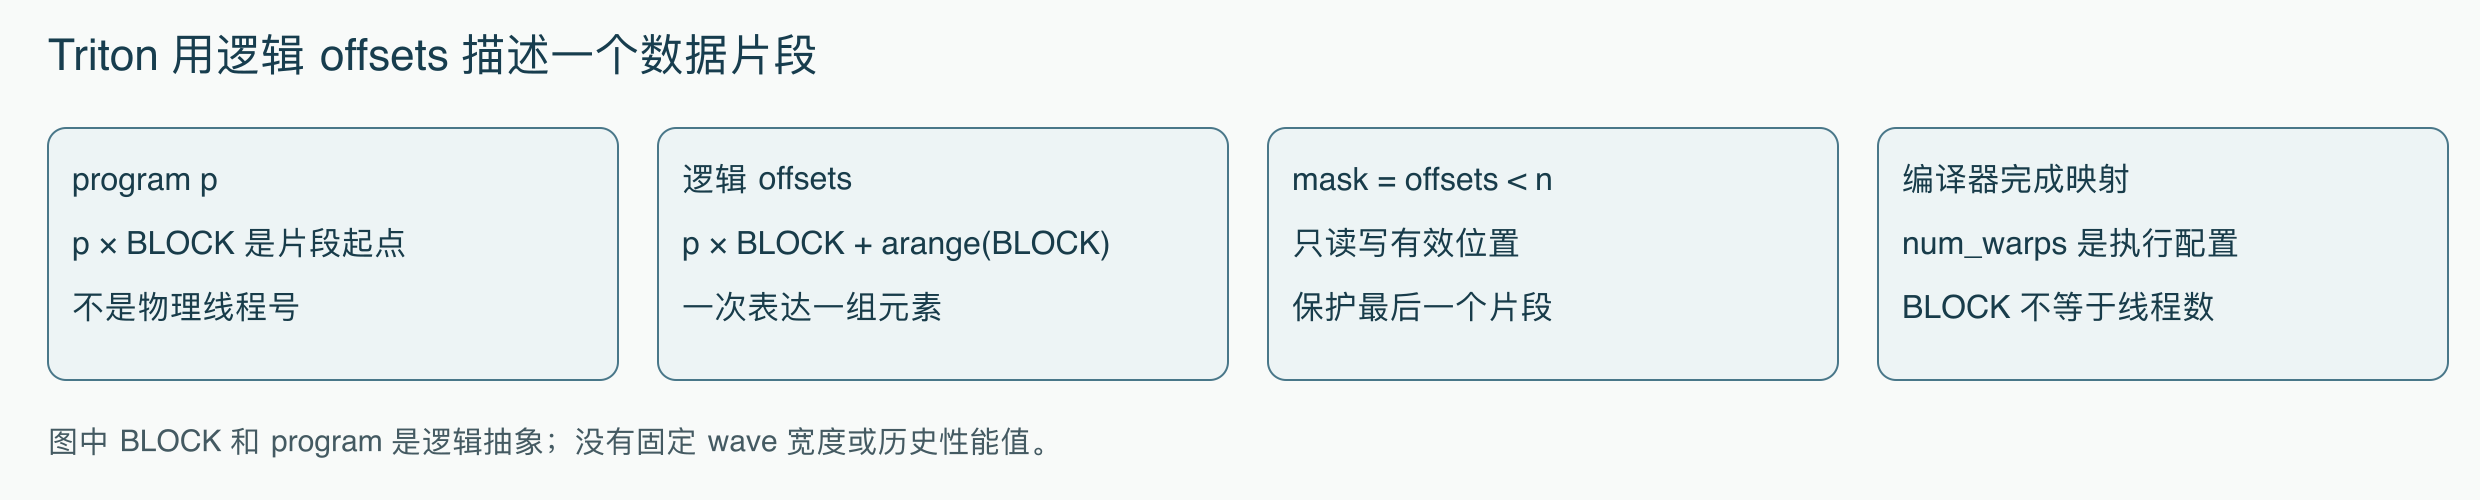

*offsets 和 mask 对应当前 Triton kernel，物理映射由编译器安排。*


In [ ]:
@triton.jit
def triton_add(a,b,c,n,BLOCK:tl.constexpr):
    offsets=tl.program_id(0)*BLOCK+tl.arange(0,BLOCK)
    valid=offsets<n
    x=tl.load(a+offsets,mask=valid,other=0)
    y=tl.load(b+offsets,mask=valid,other=0)
    tl.store(c+offsets,x+y,mask=valid)


In [ ]:
def triton_call(tile,out):
    return lambda: triton_add[(triton.cdiv(N,tile),)](a,b,out,N,BLOCK=tile,num_warps=4)
for tile in (256,1024):
    name=f'Triton tile={tile}'
    outputs[name]=torch.empty_like(a)
    calls[name]=triton_call(tile,outputs[name])
triton_round=learning.compare({k:v for k,v in calls.items() if k.startswith('Triton')},
                             reference=reference,outputs=outputs,warmup=cfg['warmup'],
                             repeat=cfg['repeat'],bytes_moved=12*N)
triton_round


In [ ]:
learning.plot_comparison(triton_round,baseline='Triton tile=256')


自动调优是继续搜索的选读入口。候选空间与 key 必须公开，调优开销留在稳态计时之外；被选中配置还要固定下来独立复测。本章先做这两个手工 tile 比较，保留不提速结果。


## 8.5 按问题选择性能分析

如果 grid cap 改变后表现异常，可采一次新的目标 trace，核对 grid 和 workgroup。若当前环境没有 profiler，能力检查会明确显示不可用。性能表是在 profiler 之外采集的。


In [ ]:
profile = profiling.kernel_trace({'hip_base':hip_base,'hip_grid':hip_grid},
                                 n=N,block=cfg['block'],launches=3,label='chapter8',
                                 grid_limits={'hip_grid': grid_cap})
print(profile['status'])
profiling.trace_summary(profile)


## 8.6 HIP 与 Triton 对照

把所有当前实现放回同一输入、dtype 和采样口径。HIP 的 float4/grid-stride 与 Triton tile 改的是不同分工；表格回答这次配置怎样表现，不代表语言天生快慢。


In [ ]:
outputs['PyTorch']=torch.empty_like(a)
calls['PyTorch']=lambda: torch.add(a,b,out=outputs['PyTorch'])
all_results=learning.compare(calls,reference=reference,outputs=outputs,
                             warmup=cfg['warmup'],repeat=cfg['repeat'],bytes_moved=12*N)
all_results


In [ ]:
learning.plot_comparison(all_results,baseline='HIP baseline')


## 8.7 负结果、适用边界与下一步

没有稳定改善也能帮助缩小假设。改变 N 后，缓存条件、block 数和尾部占比会变；不能只选最快的一次。先观察 median、样本分布和实际配置，再决定保留、回退或继续诊断。


In [ ]:
baseline_ms=all_results.loc['HIP baseline','median_ms']
all_results['relative_to_HIP_baseline']=baseline_ms/all_results['median_ms']
all_results[['median_ms','relative_to_HIP_baseline']]


## 8.8 复跑与练习

**练习**：只改变 grid_cap，重新校验并比较 baseline/grid-stride；把 N 改为 block 整数倍，再改成多 17 个元素；固定 num_warps 扫 tile，然后固定 tile 改 num_warps。每轮写出观察、假设、改动、结果和下一步。

把当前结果与源码保存，避免重新运行后丢失较慢版本。


In [ ]:
launch_specs = {
    'HIP baseline': {'block': cfg['block'], 'grid_limit': None},
    'HIP grid-stride': {'block': cfg['block'], 'grid_limit': grid_cap},
    'HIP float4': {'block': cfg['block'], 'grid_limit': grid_cap},
    'PyTorch': {'operator': 'torch.add', 'out': 'preallocated'},
}
for tile in (256, 1024):
    launch_specs[f'Triton tile={tile}'] = {'BLOCK': tile, 'num_warps': 4,
                                          'grid': [triton.cdiv(N, tile)]}
learning.save_table('part2-kernels/chapter8', all_results,
                    config={**cfg, 'n': N, 'grid_cap': grid_cap},
                    kernels=[hip_base, hip_grid, hip_vector],
                    sources={'triton_add': triton_add.src}, launches=launch_specs)


## 本章小结

逐元素输出独立，让我们直接研究数据与工作分配。HIP 和 Triton 各有自然基线；每项改动都经过尾部与非均匀输入校验，再用相同口径比较。第3篇会把这套手动实验组织成 Agent 的工具闭环。

## 延伸阅读

- [第14章：Agent 入门正文](../../../docs/part3-agent/chapter14/index.md)
- [Triton 官方 vector add 教程](https://triton-lang.org/main/getting-started/tutorials/01-vector-add.html)
